In [1]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

X_train_sains = X_train[y_train == 0]
print("Vols sains pour apprendre la normale :", len(X_train_sains))

Mounted at /content/drive
Vols sains pour apprendre la normale : 1096


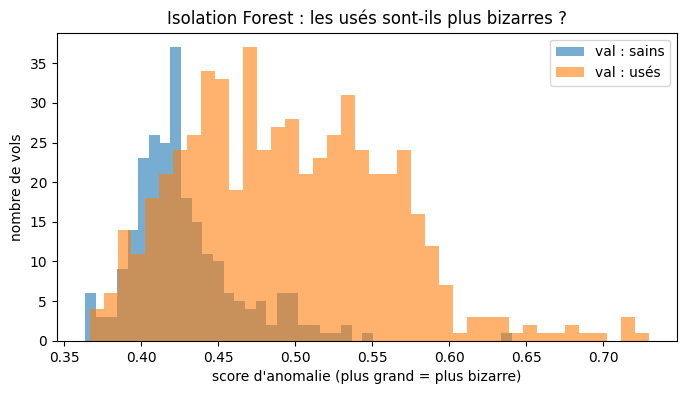

In [3]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from aeroguard.anomalies import score_anomalie

iso = IsolationForest(n_estimators=200, random_state=42).fit(X_train_sains)

score_train_sains = score_anomalie(iso, X_train_sains)
score_val = score_anomalie(iso, X_val)

plt.figure(figsize=(8, 4))
plt.hist(score_val[y_val == 0], bins=40, alpha=0.6, label="val : sains")
plt.hist(score_val[y_val == 1], bins=40, alpha=0.6, label="val : usés")
plt.xlabel("score d'anomalie (plus grand = plus bizarre)")
plt.ylabel("nombre de vols")
plt.legend()
plt.title("Isolation Forest : les usés sont-ils plus bizarres ?")
plt.show()

In [4]:
from aeroguard.anomalies import alertes, seuil_percentile
from aeroguard.evaluation import metriques, taux_par_classe

lignes = []
for p in [90, 95, 99]:
    seuil = seuil_percentile(score_train_sains, p)
    pred = alertes(score_val, seuil)
    s = {**metriques(y_val, pred, score_val), **taux_par_classe(y_val, pred)}
    lignes.append({"percentile": p, "seuil": seuil, **s})

tableau = pd.DataFrame(lignes).set_index("percentile")
tableau[["seuil", "sains_reconnus", "rappel", "precision", "fp", "fn", "f1_macro", "pr_auc"]].round(3)

,seuil,sains_reconnus,rappel,precision,fp,fn,f1_macro,pr_auc
percentile,,,,,,,,
90,0.475,0.881,0.581,0.920,29,241,0.663,0.915
95,0.493,0.918,0.485,0.933,20,296,0.612,0.915
99,0.546,0.992,0.228,0.985,2,444,0.445,0.915


In [5]:
from aeroguard.evaluation import ajouter_au_leaderboard

s95 = tableau.loc[95]
cles = ["precision", "rappel", "f1", "f1_macro", "pr_auc", "fp", "fn"]
ajouter_au_leaderboard(f"{DOSSIER}/results/leaderboard.csv", "isolation_forest_p95",
                       {k: float(s95[k]) for k in cles})
pd.read_csv(f"{DOSSIER}/results/leaderboard.csv").sort_values("f1_macro", ascending=False)

,modele,f1_macro,pr_auc,rappel,precision,f1,fp,fn
2,logistique,0.886000,0.987000,0.932000,0.932000,0.932000,39.0,39.0
3,logistique_balanced,0.882083,0.986936,0.873043,0.974757,0.921101,NaN,NaN
4,random_forest,0.843745,0.984866,0.951304,0.882258,0.915481,73.0,28.0
1,copieur_knn,0.763000,0.903000,0.843000,0.866000,0.855000,75.0,90.0
5,isolation_forest_p95,0.612416,0.915238,0.485217,0.933110,0.638444,20.0,296.0
0,bete,0.412000,0.702000,1.000000,0.702000,0.825000,244.0,0.0
